# Setup

In [361]:
from typing import Optional
from collections import defaultdict

import torch
from torch.utils.data import random_split
import torch_geometric as tg
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj, to_dense_batch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash
from tqdm import trange

In [362]:
# Prepare device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load data
dataset = TUDataset(root='./data/', name='MUTAG').to(device)
node_feature_dim = 7

# Split into training and validation
rng = torch.Generator().manual_seed(0)
train_dataset, validation_dataset, test_dataset = random_split(dataset, (100, 44, 44), generator=rng)

# Create dataloader for training and validation
train_loader = DataLoader(train_dataset, batch_size=100)
validation_loader = DataLoader(validation_dataset, batch_size=44)
test_loader = DataLoader(test_dataset, batch_size=44)

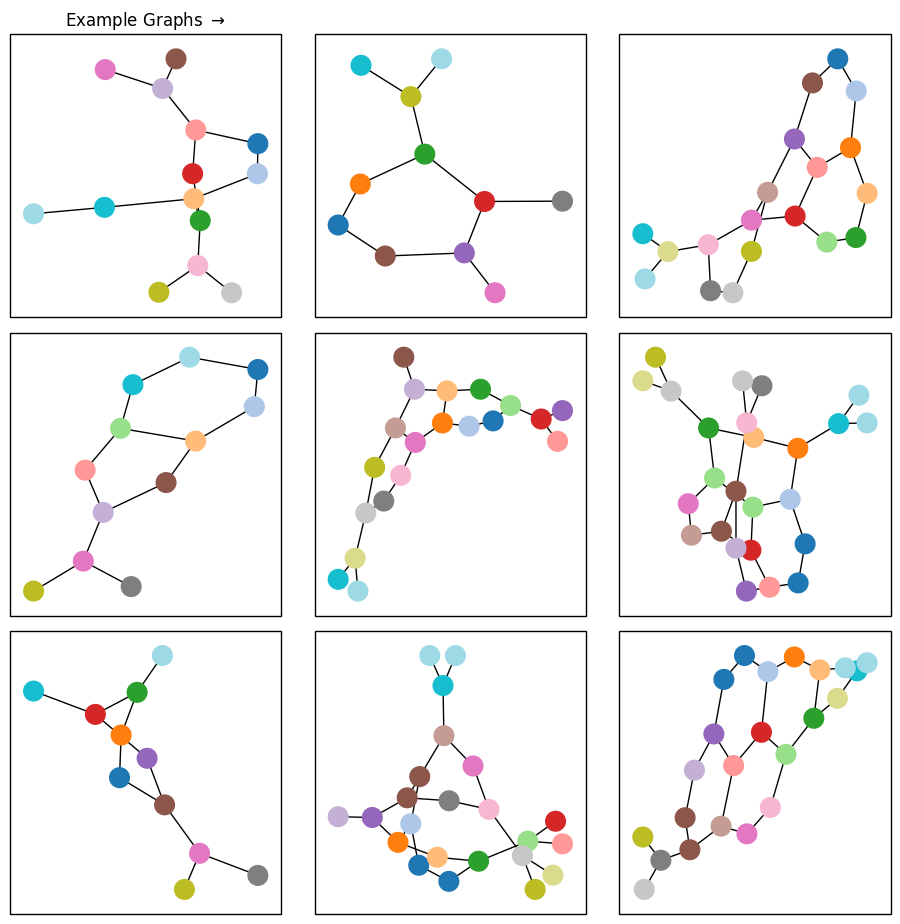

In [398]:
def construct_adj_matrix(edge_index, batch, max_num_nodes: Optional[int] = None):
    graphs, g_sizes = torch.unique(batch, return_counts=True)
    max_size = torch.max(g_sizes) if max_num_nodes is None else max_num_nodes
    A = torch.zeros((len(graphs), max_size, max_size))
    gs = torch.tensor([graphs[batch[e]] for e in edge_index[0]])
    
    global_to_local_idx = torch.hstack([torch.arange(g_size) for g_size in g_sizes])
    A[gs, global_to_local_idx[edge_index[0]], global_to_local_idx[edge_index[1]]] = 1

    return A, g_sizes


def plot_graph(ax, A):
    idx_non_empty = np.argwhere(~np.all(A == 0, axis=0))
    A = A[idx_non_empty[:, 0], :][:, idx_non_empty[:, 0]]  # Keep only non-empty rows and columns

    G = nx.from_numpy_array(A)  # Create a graph from the adjacency matrix
    num_nodes = A.shape[0]
    node_colors = plt.cm.tab20(np.linspace(0, 1, num_nodes))
    nx.draw(G, ax=ax, node_size=int(200), node_color=node_colors[:num_nodes])
    
    rect = patches.Rectangle((0, 0), 1, 1,                # Coordinates and size
                                transform=ax.transAxes,   # Use Axes coordinates
                                linewidth=1,
                                edgecolor='black',
                                facecolor='none',         # No fill
                                clip_on=False,            # Draw lines even if slightly outside bounds
                                zorder=10)                # Draw on top

    # Add the rectangle to the Axes
    ax.add_patch(rect)


def draw_graphs(As: np.ndarray, w: int, h: int, title: Optional[str] = None) -> None:
    fig, axes = plt.subplots(h, w, figsize=(w * 3, h * 3))
    if title is not None:
        axes[0, 0].set_title(f"{title} $\\to$")
    
    fig.tight_layout(pad=-1.0)

    for i in range(h*w):
        plot_graph(axes[i // w, i % w], As[i])


def get_all_graphs(dataset: TUDataset):
    batch = next(iter(DataLoader(dataset, batch_size=len(dataset))))
    adj, sizes = construct_adj_matrix(batch.edge_index.cpu(), batch.batch.cpu())
    adj, sizes = adj.cpu().numpy(), sizes.cpu().numpy()

    return [a[:s, :s] for a, s in zip(adj, sizes)]



example_batch = next(iter(train_loader))
example_adjacency, example_sizes = construct_adj_matrix(example_batch.edge_index.cpu(), example_batch.batch.cpu())
example_adjacency, example_sizes = example_adjacency.cpu().numpy(), example_sizes.cpu().numpy()
draw_graphs([a[:s, :s] for a, s in zip(example_adjacency, example_sizes)], 3, 3, "Example Graphs")
plt.show()

# Baseline

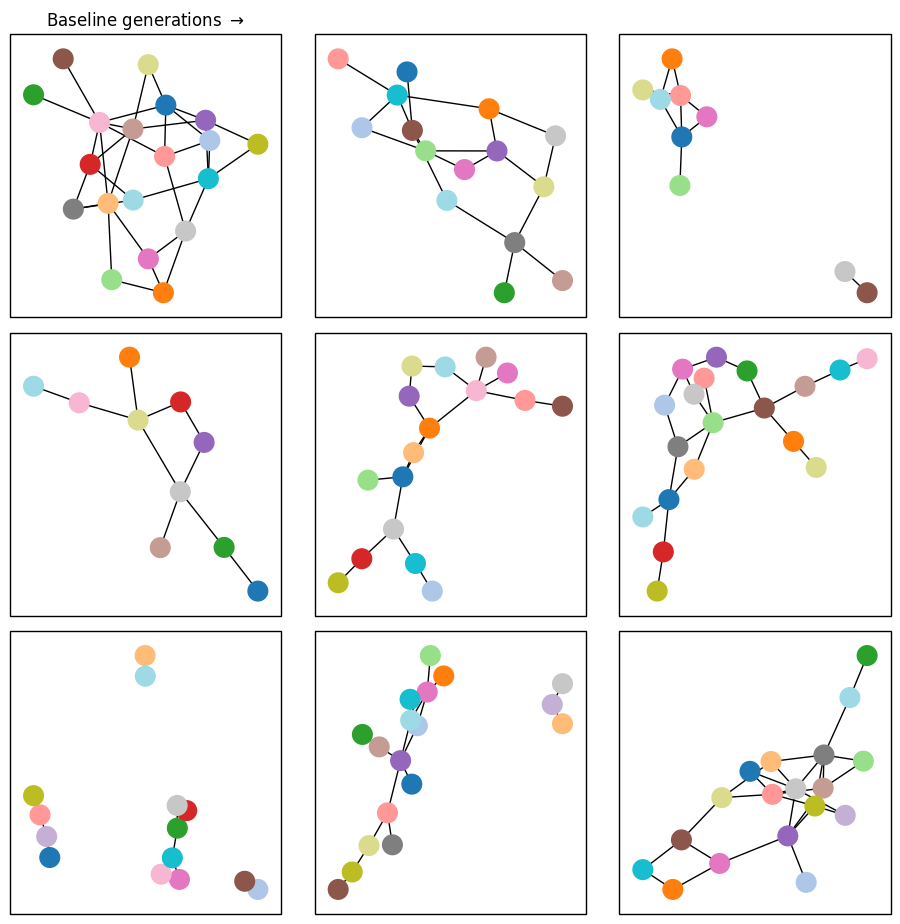

In [399]:
node_count_to_graphs: defaultdict[int, list[tg.data.data.Data]] = defaultdict(list)
for graph in train_dataset:
    node_count_to_graphs[graph.num_nodes].append(graph)

node_count_density: np.ndarray = np.zeros(len(node_count_to_graphs))
node_count_keys: list[int] = sorted(node_count_to_graphs.keys())
for i, node_count in enumerate(node_count_keys):
    node_count_density[i] = len(node_count_to_graphs[node_count])
node_count_density /= np.sum(node_count_density)

link_probability: np.ndarray = np.zeros(len(node_count_to_graphs))
for i, node_count in enumerate(node_count_keys):
    graphs = node_count_to_graphs[node_count]
    probs = np.array([
        # NOTE: Not dividing by two, because num_edges is counted twice
        graph.num_edges / (node_count * (node_count - 1))
        for graph in graphs
    ])

    link_probability[i] = np.mean(probs)


def sample_baseline(n: int, seed: int) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    node_count_idx = rng.choice(len(node_count_keys), size=n, p=node_count_density)

    adjacency_matrices: list[np.ndarray] = []
    for count_idx in node_count_idx:
        count = node_count_keys[count_idx]
        prob = link_probability[count_idx]
        
        triangle_matrix = rng.choice([0, 1], size=(int((count*count - count)/2),), p=[1 - prob, prob])
        adjacency_matrix = np.zeros((count, count), dtype=int)
        adjacency_matrix[np.tril_indices(count, k=-1)] = triangle_matrix
        adjacency_matrix += adjacency_matrix.T

        adjacency_matrices.append(adjacency_matrix)

    return adjacency_matrices


draw_graphs(sample_baseline(9, 0), 3, 3, "Baseline generations")

 # DGM

In [366]:
class GraphEncoder(torch.nn.Module):
    def __init__(self, max_node_count: int, node_feature_dim: int, node_state_dim: int, message_passing_rounds: int, prior_dim: int) -> None:
        super().__init__()

        self.max_node_count = max_node_count
        self.node_feature_dim = node_feature_dim
        self.node_state_dim = node_state_dim
        self.message_passing_rounds = message_passing_rounds
        self.prior_dim = prior_dim

        self.input_mlp = torch.nn.Sequential(
            torch.nn.Linear(self.node_feature_dim, self.node_state_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(self.node_state_dim, self.node_state_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(self.node_state_dim, self.node_state_dim)
        )

        self.msg_aggr_attn = torch.nn.ModuleList([
            torch.nn.MultiheadAttention(self.node_state_dim, num_heads=1)
            for _ in range(self.message_passing_rounds)
        ])
        self.update_mlp = torch.nn.ModuleList([
            torch.nn.Sequential(
                torch.nn.Linear(self.node_state_dim, self.node_state_dim),
                torch.nn.ReLU(),
                torch.nn.Linear(self.node_state_dim, self.node_state_dim),
                torch.nn.ReLU(),
                torch.nn.Linear(self.node_state_dim, self.node_state_dim),
            )
            for _ in range(self.message_passing_rounds)
        ])


        self.output_mlp = torch.nn.Sequential(
            torch.nn.Linear(self.max_node_count*self.node_state_dim, self.node_state_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(self.node_state_dim, self.node_state_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(self.node_state_dim, 2*self.prior_dim),
        )



    def forward(self, data: tg.data.Data) -> torch.Tensor:
        state = self.input_mlp(data.x)

        attn_mask = torch.full((len(state), len(state)), True, dtype=torch.bool, device=state.device)
        attn_mask[data.edge_index[0], data.edge_index[1]] = False
        attn_mask[data.edge_index[1], data.edge_index[0]] = False


        for r in range(self.message_passing_rounds):
            aggregated = self.msg_aggr_attn[r](state, state, state, attn_mask=attn_mask, need_weights=False)[0]
            aggregated = torch.nn.functional.normalize(state + aggregated, dim=1)

            state = torch.nn.functional.normalize(state + self.update_mlp[r](aggregated), dim=1)


        state = to_dense_batch(state, batch=data.batch, max_num_nodes=self.max_node_count)[0]
        # NOTE: This breaks permutation invariance
        state = state.view(state.shape[0], -1)

        return self.output_mlp(state)



class GraphDecoder(torch.nn.Module):
    def __init__(self, prior_dim: int, max_node_count:int) -> None:
        super().__init__()

        self.prior_dim = prior_dim
        self.max_node_count = max_node_count

        self.decoder_mlp = torch.nn.Sequential(
            torch.nn.Linear(self.prior_dim, 8*self.prior_dim, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(8*self.prior_dim, 16*self.prior_dim, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(16*self.prior_dim, 32*self.prior_dim, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(32*self.prior_dim, 64*self.prior_dim, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(64*self.prior_dim, int(self.max_node_count*(self.max_node_count - 1) / 2), bias=False),
            torch.nn.Sigmoid()
        )


    def triangle_to_adjacency(self, triangle_matrix: torch.Tensor) -> torch.Tensor:
        adjacency_matrices = torch.zeros((len(triangle_matrix), self.max_node_count, self.max_node_count), dtype=triangle_matrix.dtype, device=triangle_matrix.device)
        adjacency_matrices[:, *torch.tril_indices(self.max_node_count, self.max_node_count, offset=-1)] = triangle_matrix
        adjacency_matrices = adjacency_matrices + torch.transpose(adjacency_matrices, 1, 2)

        return adjacency_matrices


    def forward(self, latents: torch.Tensor) -> torch.Tensor:
        return self.decoder_mlp(latents)



class GraphVae(torch.nn.Module):
    def __init__(self, max_node_count: int, node_feature_dim: int, node_state_dim: int, message_passing_rounds: int, prior_dim: int):
        super().__init__()

        self.max_node_count = max_node_count
        self.node_feature_dim = node_feature_dim
        self.node_state_dim = node_state_dim
        self.message_passing_rounds = message_passing_rounds
        self.prior_dim = prior_dim

        self.encoder = GraphEncoder(
            max_node_count=max_node_count,
            node_feature_dim=self.node_feature_dim,
            node_state_dim=self.node_state_dim,
            message_passing_rounds=self.message_passing_rounds,
            prior_dim=self.prior_dim
        )
        
        self.decoder = GraphDecoder(self.prior_dim, self.max_node_count)


    def sample(self, mu: torch.Tensor, std: Optional[torch.Tensor]) -> torch.Tensor:
        if std is None:
            return mu

        return mu + std*torch.randn_like(mu)


    def negative_elbo(self, mu: torch.Tensor, std: torch.Tensor, triangle_pred: torch.Tensor, triangle_true: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        ll = torch.nn.functional.binary_cross_entropy(triangle_pred, triangle_true)

        n, dim = triangle_pred.shape
        kl_factor = 0.001
        kl = kl_factor * (-torch.log(std).sum() + ((std**2).sum() + (mu**2).sum()) / 2 - dim/2) / n

        return ll + kl, ll, kl


    def forward(self, data: tg.data.Data) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        latents = self.encoder(data)
        mu = latents[:, :self.prior_dim]
        # NOTE: Using constant std because it performs better
        # std = torch.exp(latents[:, self.prior_dim:])
        std = torch.tensor(0.1, device=latents.device)

        samples = self.sample(mu, std)

        triangle_pred = self.decoder(samples)
        adjacency_matrix_true = to_dense_adj(data.edge_index, batch=data.batch, max_num_nodes=self.max_node_count)
        triangle_true = adjacency_matrix_true[:, *torch.tril_indices(self.max_node_count, self.max_node_count, offset=-1)]

        return self.negative_elbo(mu, std, triangle_pred, triangle_true)

100%|██████████| 400/400 [00:55<00:00,  7.18it/s, train_kl=-0.00148, train_ll=0.0246, train_loss=0.0231, val_kl=-0.00239, val_ll=0.222, val_loss=0.22]   


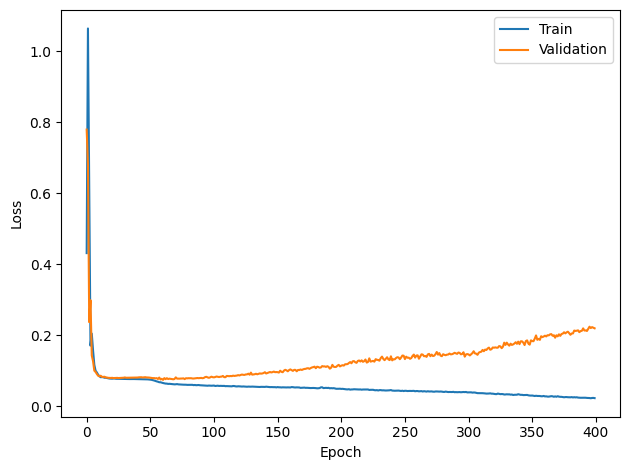

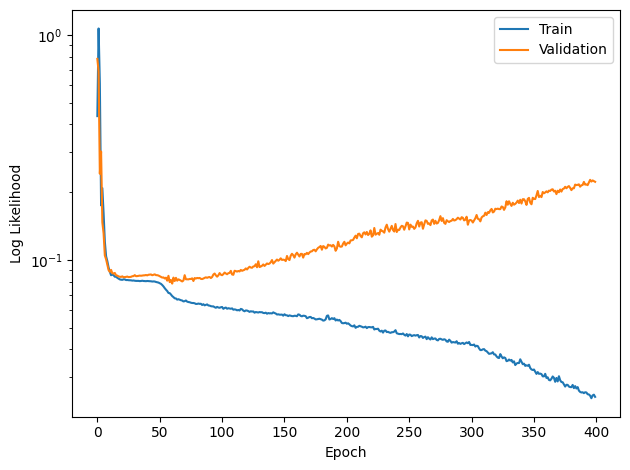

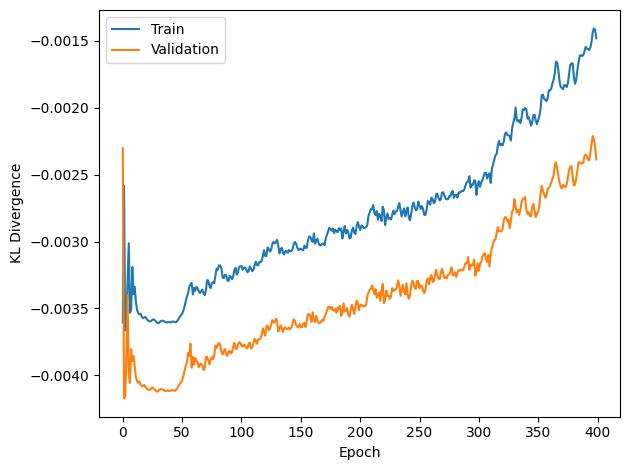

In [ ]:
# TODO: Store model weights

model = GraphVae(
    max_node_count=max(node_count_keys),
    node_feature_dim=node_feature_dim,
    node_state_dim=512,
    message_passing_rounds=4,
    prior_dim=256
).to(device)


optimizer = torch.optim.AdamW(
    model.parameters(),
    # [
    #     {"params": model.encoder.parameters(), "lr": 1e-3},
    #     {"params": model.decoder.parameters(), "lr": 1e-4},
    # ],
    lr=1e-3,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.995)

train_loss = []
train_ll = []
train_kl = []
val_loss = []
val_ll = []
val_kl = []

epochs = 400
batch_size = 50

for epoch in (pbar := trange(epochs)):
    # Training
    model.train()
    train_loss.append(0.)
    train_kl.append(0.)
    train_ll.append(0.)

    for data in DataLoader(train_dataset, batch_size=batch_size, shuffle=True):
        loss, ll, kl = model(data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss[-1] += loss.item()
        train_ll[-1] += ll.item()
        train_kl[-1] += kl.item()

    scheduler.step()

    # Validation
    with torch.no_grad():
        model.eval()
        val_loss.append(0.)
        val_ll.append(0.)
        val_kl.append(0.)

        for data in validation_loader:
            loss, ll, kl = model(data)

            val_loss[-1] += loss.item()
            val_ll[-1] += ll.item()
            val_kl[-1] += kl.item()
            



    train_loss[-1] /= len(train_loader)
    train_ll[-1] /= len(train_loader)
    train_kl[-1] /= len(train_loader)
    val_loss[-1] /= len(validation_loader)
    val_ll[-1] /= len(validation_loader)
    val_kl[-1] /= len(validation_loader)

    pbar.set_postfix(
        train_loss=train_loss[-1],
        train_ll=train_ll[-1],
        train_kl=train_kl[-1],
        val_loss=val_loss[-1],
        val_ll=val_ll[-1],
        val_kl=val_kl[-1]
    )


# torch.save(model.state_dict(), 'model.pth')


plt.figure('Loss').clf()
plt.plot(train_loss, label='Train')
plt.plot(val_loss, label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()

plt.figure('LL').clf()
plt.plot(train_ll, label='Train')
plt.plot(val_ll, label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Log Likelihood')
plt.yscale('log')
plt.tight_layout()

plt.figure('KL').clf()
plt.plot(train_kl, label='Train')
plt.plot(val_kl, label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.tight_layout()

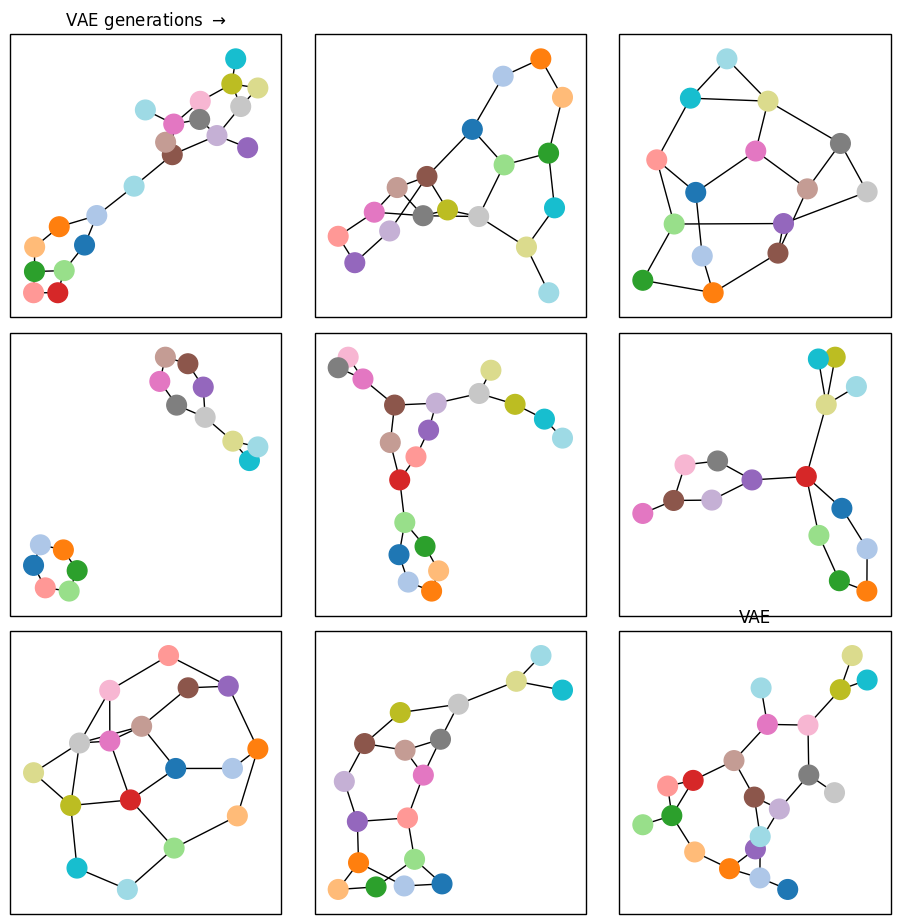

In [407]:
@torch.no_grad()
def sample_model(n: int, model: GraphVae, seed: int) -> list[np.ndarray]:
    model_initial_mode = model.decoder.training
    model.decoder.eval()


    rng = torch.Generator(device).manual_seed(seed)
    latents = torch.randn(n, model.prior_dim, generator=rng, device=device)

    triangle = model.decoder(latents)
    triangle = torch.rand(triangle.shape, generator=rng, device=device) < triangle
    full_adjacency_matrices = model.decoder.triangle_to_adjacency(triangle)
    full_adjacency_matrices = full_adjacency_matrices.cpu().numpy()
    full_adjacency_matrices = full_adjacency_matrices.astype(int)


    adjacency_matrices: list[np.ndarray] = []
    for adj in full_adjacency_matrices:
        # Keep only non-empty rows and columns
        idx_non_empty = np.argwhere(~np.all(adj == 0, axis=0))
        adjacency_matrices.append(adj[idx_non_empty[:, 0], :][:, idx_non_empty[:, 0]])


    model.decoder.train(model_initial_mode)


    return adjacency_matrices


model_adjacency_generated = sample_model(9, model, seed=5)
draw_graphs(model_adjacency_generated, 3, 3, "VAE generations")
plt.title("VAE")
plt.show()

# Evaluation

In [384]:
def hash_graph(A):
    """Takes an adjecency matrix, converts it to a nx.Graph object and hashs it"""
    if torch.is_tensor(A): 
        A = A.detach().numpy() 
    G = nx.from_numpy_array(A, create_using=nx.DiGraph)
    wl_hash = weisfeiler_lehman_graph_hash(G)
    return wl_hash 

def compare_graph_sets(As1, As2): 
    # Hash all graphs and store in dictonaries
    wls1 = defaultdict(lambda: 0)
    wls2 = defaultdict(lambda: 0)
    for A in As1: wls1[hash_graph(A)] += 1
    for A in As2: wls2[hash_graph(A)] += 1
    
    # Unique in each of the sets 
    unique1 = len(wls1.keys())
    unique2 = len(wls2.keys())
    
    # Samples form As1 novel for As2
    novel1 = 0 
    un1 = 0
    for wl in wls1.keys(): 
        if wl not in wls2.keys():
            novel1 += wls1[wl]
            un1 += 1

    # Samples form As2 novel for As1
    novel2 = 0 
    un2 = 0
    for wl in wls2.keys(): 
        if wl not in wls1.keys():
            novel2 += wls2[wl]
            un2 += 1
    
    return (unique1, novel1, un1), (unique2, novel2, un2)
    

def node_degree_dist(As):
    degrees = []
    for A in As: 
        degrees += list(A.sum(axis=-1).flatten())
    return degrees

def clustering_coef_dist(As): 
    clustering_coefs = []
    for A in As: 
        G = nx.from_numpy_array(A, create_using=nx.DiGraph)
        clustering_coefs += list(nx.clustering(G).values())
    return clustering_coefs

def eigenvector_centrality_dist(As): 
    centralities = []
    for A in As: 
        eigenvalues, eigenvectors = np.linalg.eigh(A)
        max_idx = np.argmax(eigenvalues)
        principal_eigenvector = eigenvectors[:, max_idx]
        centralities += list(principal_eigenvector * (principal_eigenvector.sum() / abs(principal_eigenvector.sum())))
    
    return centralities
        
# TODO fix the issue that we have max nodes everywhere
def get_statistics_for_set_of_graphs(As): 
    """
    Computes the distribution of: node_degree, clustering_coe, eigenvec_cen 
    over all graphs 
    As should be a list of square matrices, possible of different sizes. 
    """
    node_degree = node_degree_dist(As)
    clustering_coef = clustering_coef_dist(As)
    centralities = eigenvector_centrality_dist(As)
    return node_degree, clustering_coef, centralities

In [385]:
sample_count = 1000

samples_training_all = get_all_graphs(train_dataset)
samples_baseline = sample_baseline(sample_count, seed=0)
samples_model = sample_model(sample_count, model, seed=0)

print(compare_graph_sets(samples_training_all, samples_baseline))
print(compare_graph_sets(samples_training_all, samples_model))

dist_degree_training, dist_clustering_training, dist_centralities_training = get_statistics_for_set_of_graphs(samples_training_all)
dist_degree_baseline, dist_clustering_baseline, dist_centralities_baseline = get_statistics_for_set_of_graphs(samples_baseline)
dist_degree_model, dist_clustering_model, dist_centralities_model = get_statistics_for_set_of_graphs(samples_model)

((85, 100, 85), (1000, 1000, 1000))
((85, 99, 84), (946, 998, 945))


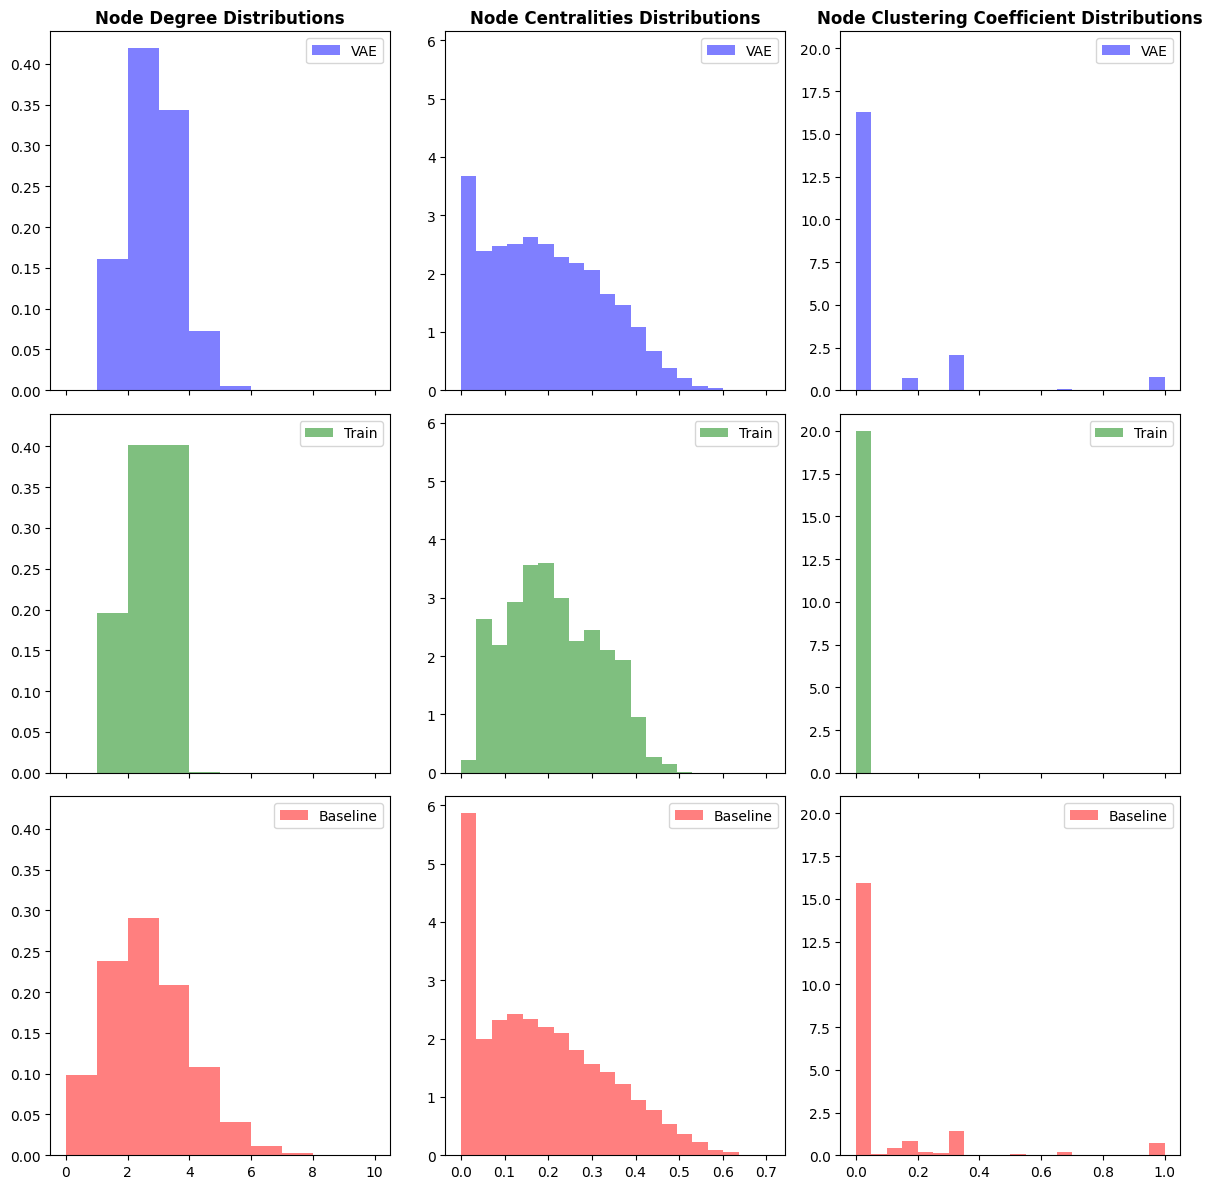

In [386]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# ---- 1. Node Degree Distributions ----
all_degrees = np.concatenate([dist_degree_model, dist_degree_training, dist_degree_baseline])
bins_degree = np.histogram_bin_edges(all_degrees, bins=int(all_degrees.max()))

axes[0,0].hist(dist_degree_model, bins=bins_degree, alpha=0.5, label='VAE', color='blue', density=True)
axes[1,0].hist(dist_degree_training, bins=bins_degree, alpha=0.5, label='Train', color='green', density=True)
axes[2,0].hist(dist_degree_baseline, bins=bins_degree, alpha=0.5, label='Baseline', color='red', density=True)
axes[0,0].set_title('Node Degree Distributions',fontweight='bold')

# ---- 2. Node Centrality Distributions ----
all_centralities = np.concatenate([dist_centralities_model, dist_centralities_training, dist_centralities_baseline])
bins_centrality = np.histogram_bin_edges(all_centralities, bins=20)

axes[0,1].hist(dist_centralities_model, bins=bins_centrality, alpha=0.5, label='VAE', color='blue', density=True)
axes[1,1].hist(dist_centralities_training, bins=bins_centrality, alpha=0.5, label='Train', color='green', density=True)
axes[2,1].hist(dist_centralities_baseline, bins=bins_centrality, alpha=0.5, label='Baseline', color='red', density=True)
axes[0,1].set_title('Node Centralities Distributions',fontweight='bold')

# ---- 3. Clustering Coefficient Distributions ----
all_clustering = np.concatenate([dist_clustering_model, dist_clustering_training, dist_clustering_baseline])
bins_clustering = np.histogram_bin_edges(all_clustering, bins=20)

axes[0, 2].hist(dist_clustering_model, bins=bins_clustering, alpha=0.5, label='VAE', color='blue', density=True)
axes[1, 2].hist(dist_clustering_training, bins=bins_clustering, alpha=0.5, label='Train', color='green', density=True)
axes[2, 2].hist(dist_clustering_baseline, bins=bins_clustering, alpha=0.5, label='Baseline', color='red', density=True)
axes[0, 2].set_title('Node Clustering Coefficient Distributions', fontweight='bold')

for j in range(3):  
    xmins, xmaxs, ymins, ymaxs = [], [], [], []
    for i in range(3):  
        xlim = axes[i, j].get_xlim()
        ylim = axes[i, j].get_ylim()
        xmins.append(xlim[0])
        xmaxs.append(xlim[1])
        ymins.append(ylim[0])
        ymaxs.append(ylim[1])
        axes[i, j].legend()
        if i < 2:
            axes[i, j].set_xticklabels([])
    
    # Uniform limits for column
    xlim = (min(xmins), max(xmaxs))
    ylim = (min(ymins), max(ymaxs))


    for i in range(3):
        axes[i, j].set_xlim(xlim)
        axes[i, j].set_ylim(ylim)

plt.tight_layout()
plt.show()